# Las galaxias estaban ahí. El ruido las tapaba.

Una IA aprende cómo se comporta el ruido entre exposiciones distintas del James Webb y lo descuenta. Resultado: 3 veces más candidatos a galaxias del universo temprano en el mismo dato.

**Paper:** [Deeper detection limits in astronomical imaging using self-supervised spatiotemporal denoising](https://doi.org/10.1126/science.ady9404) · *Science, 2026*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-02-asteris-denoising-imagenes-jwst/notebook.ipynb)

📺 **Video:** [Pendiente]

## El problema

Cuando un telescopio mira un parche de cielo durante horas, la imagen final no es perfecta. Tiene **ruido**: fotones cósmicos, fluctuaciones del detector, residuos de calibración. Para galaxias muy débiles —las del universo temprano, justo después del Big Bang— ese ruido las tapa.

La forma clásica de reducirlo es **promediar muchas exposiciones** (coadding). Funciona, pero llega un techo: el ruido aleatorio baja con la raíz de N, y el correlacionado no baja casi nada.

ASTERIS (*Astronomical Self-supervised Transformer-based Denoising*) cambia el enfoque. Es una red neuronal tipo transformer que **aprende cómo se ve el ruido** mirando muchas exposiciones del mismo cielo. Una vez entrenada, separa señal de ruido sin tocar las posiciones ni los flujos de las galaxias reales.

El equipo lo aplicó al campo profundo GOODS-South del James Webb (JADES) y publicó el catálogo de candidatos a galaxias de alto redshift que encontró. Eso es lo que vamos a explorar.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
MUV_UMBRAL_TRADICIONAL = -18.0    # Magnitud límite típica de búsquedas pre-ASTERIS
Z_REIONIZACION_FIN = 6.0          # Fin de la reionización cósmica (referencia)
Z_PRIMERAS_ESTRELLAS = 15.0       # Era de primeras estrellas (Population III)
FUENTE = 'Fuente: Guo et al. (2026), Science | Datos: Supplementary data_s1'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_F115W = '#2563EB'   # azul — z ~ 8-10
COLOR_F150W = '#7C3AED'   # violeta — z ~ 12-15
COLOR_F200W = '#DC2626'   # rojo — z ~ 18-21 (extremos)

# ══════════════════════════════════════════════════════════════
# Imports
# ══════════════════════════════════════════════════════════════
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local en el repo o fallback al raw de GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# ══════════════════════════════════════════════════════════════
# Carga del catálogo
# ══════════════════════════════════════════════════════════════
df = pd.read_csv('datos/science.ady9404_data_s1.csv')
print(f'Catálogo ASTERIS: {len(df)} candidatos')
print(f'Filtros dropout: {df.drop_out.value_counts(dropna=False).to_dict()}')
print(f'Redshift fotométrico — mediana: {df.zphot.median():.2f} | rango: {df.zphot.min():.2f}–{df.zphot.max():.2f}')
print(f'Magnitud UV (M_UV) — mediana: {df.MUV.median():.2f}')

Catálogo ASTERIS: 163 candidatos
Filtros dropout: {'F115W': 125, 'F150W': 33, 'F200W': 4, nan: 1}
Redshift fotométrico — mediana: 9.80 | rango: 2.08–21.04
Magnitud UV (M_UV) — mediana: -17.20


## El catálogo

163 candidatos a galaxias del universo temprano en un parche del cielo del tamaño de un grano de arroz a un brazo de distancia.

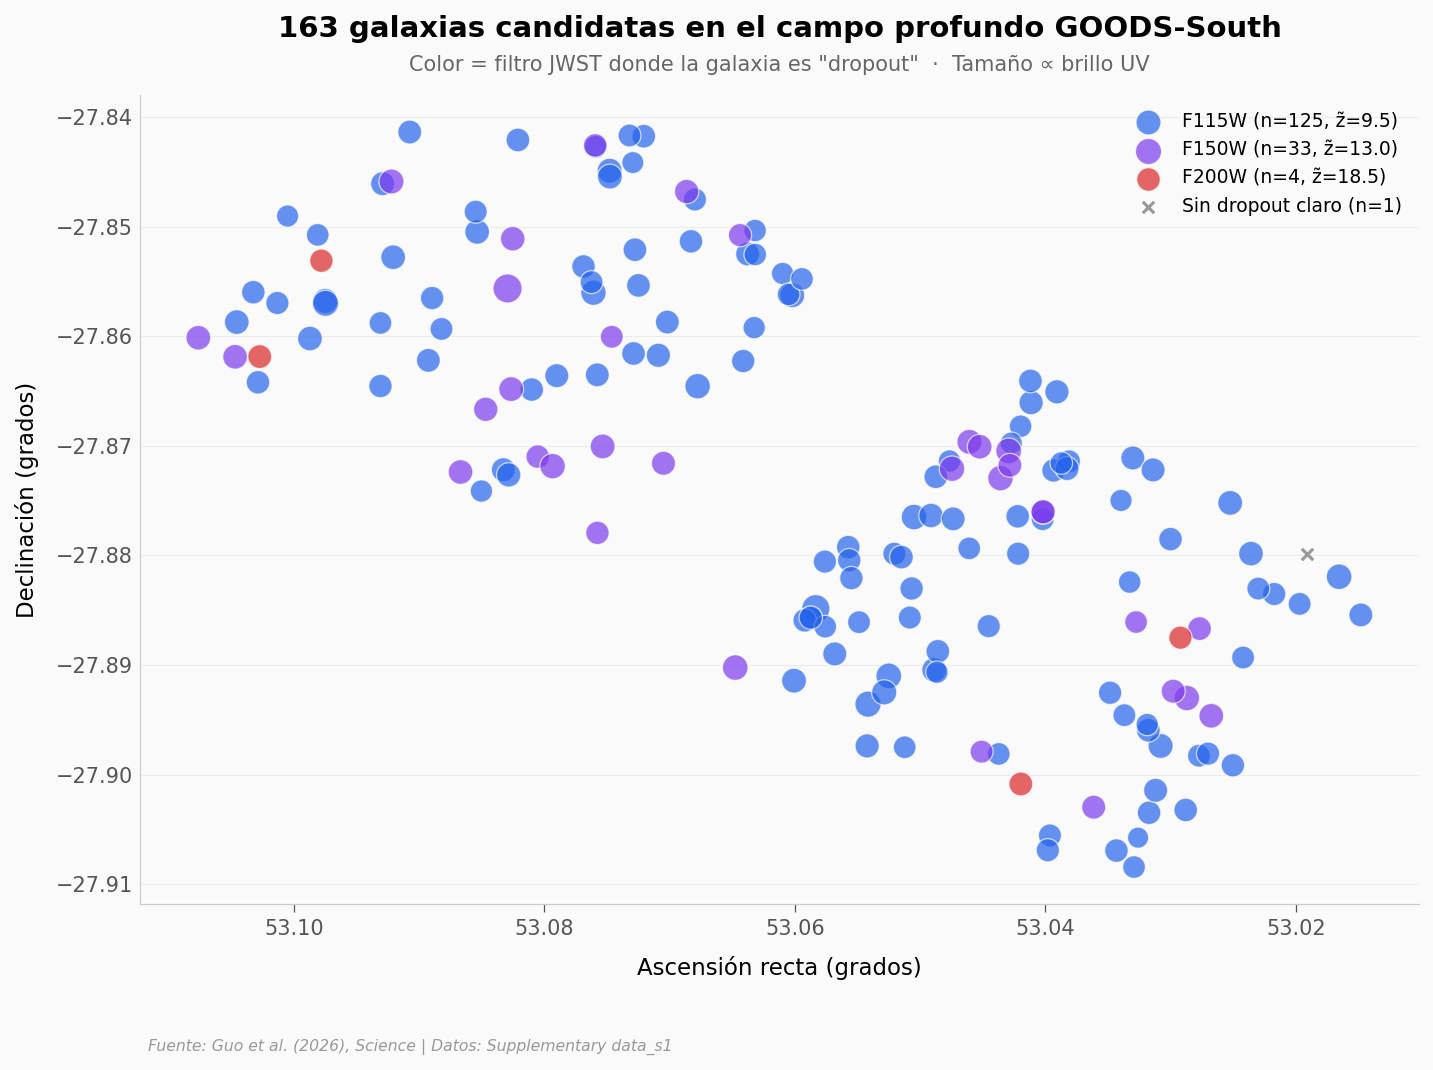

In [2]:
fig, ax = plt.subplots(figsize=(11, 7))

# Filtrar la fila con drop_out='None' (interloper de baja-z) para los grupos por filtro
df_main = df[df.drop_out.notna()].copy()
df_other = df[df.drop_out.isna()].copy()

# Tamaño del marcador proporcional al brillo (más brillante = mayor)
# MUV es magnitud absoluta UV: más NEGATIVO = más brillante
size = (-df_main.MUV - 10) * 18

# Scatter por filtro dropout
for fname, color in [('F115W', COLOR_F115W), ('F150W', COLOR_F150W), ('F200W', COLOR_F200W)]:
    sub = df_main[df_main.drop_out == fname]
    s = (-sub.MUV - 10) * 18
    z_med = sub.zphot.median()
    ax.scatter(sub.RA, sub.DEC, s=s, color=color, alpha=0.7,
               edgecolors='white', linewidths=0.6, zorder=5,
               label=f'{fname} (n={len(sub)}, z̃={z_med:.1f})')

# Outlier 'None'
if len(df_other) > 0:
    ax.scatter(df_other.RA, df_other.DEC, s=30, color='#999999',
               marker='x', linewidths=1.5, zorder=4,
               label=f'Sin dropout claro (n={len(df_other)})')

ax.set_title('163 galaxias candidatas en el campo profundo GOODS-South',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Color = filtro JWST donde la galaxia es "dropout"  ·  Tamaño ∝ brillo UV',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Ascensión recta (grados)', fontsize=11)
ax.set_ylabel('Declinación (grados)', fontsize=11)
ax.invert_xaxis()  # Convención astronómica: RA crece hacia el este (izquierda en el cielo)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_mapa_cielo.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:**

- Los candidatos están concentrados en un campo de **0.09° × 0.07°** — más pequeño que la Luna llena vista desde la Tierra. En ese parche minúsculo el James Webb observó cientos de horas para llegar tan profundo.
- La gran mayoría son **F115W dropouts** (76.7%). Esto significa que su luz desaparece en el filtro F115W pero aparece en filtros más rojos: el corte de Lyman a 1216 Å se ha desplazado hasta ~1.15 μm, lo que ubica a la galaxia en *z ~ 8–10*.
- Los **F150W dropouts** (rojo violeta) viven a *z ~ 12–15*. Y los pocos **F200W dropouts** son los extremos: galaxias del universo cuando tenía menos de 250 millones de años.

El tamaño de los puntos da la pista del descubrimiento: la mayoría son **chiquitos**. Galaxias débiles. El catálogo no está dominado por monstruos brillantes — está dominado por la población que antes el ruido tapaba.

## ¿A qué época estamos mirando?

El **redshift fotométrico** (zphot) traduce a tiempo cósmico:

- z = 9   →  el universo tenía ~540 millones de años
- z = 12  →  ~360 millones de años
- z = 18  →  ~210 millones de años (era de primeras estrellas)

Veamos cómo se distribuye el catálogo.

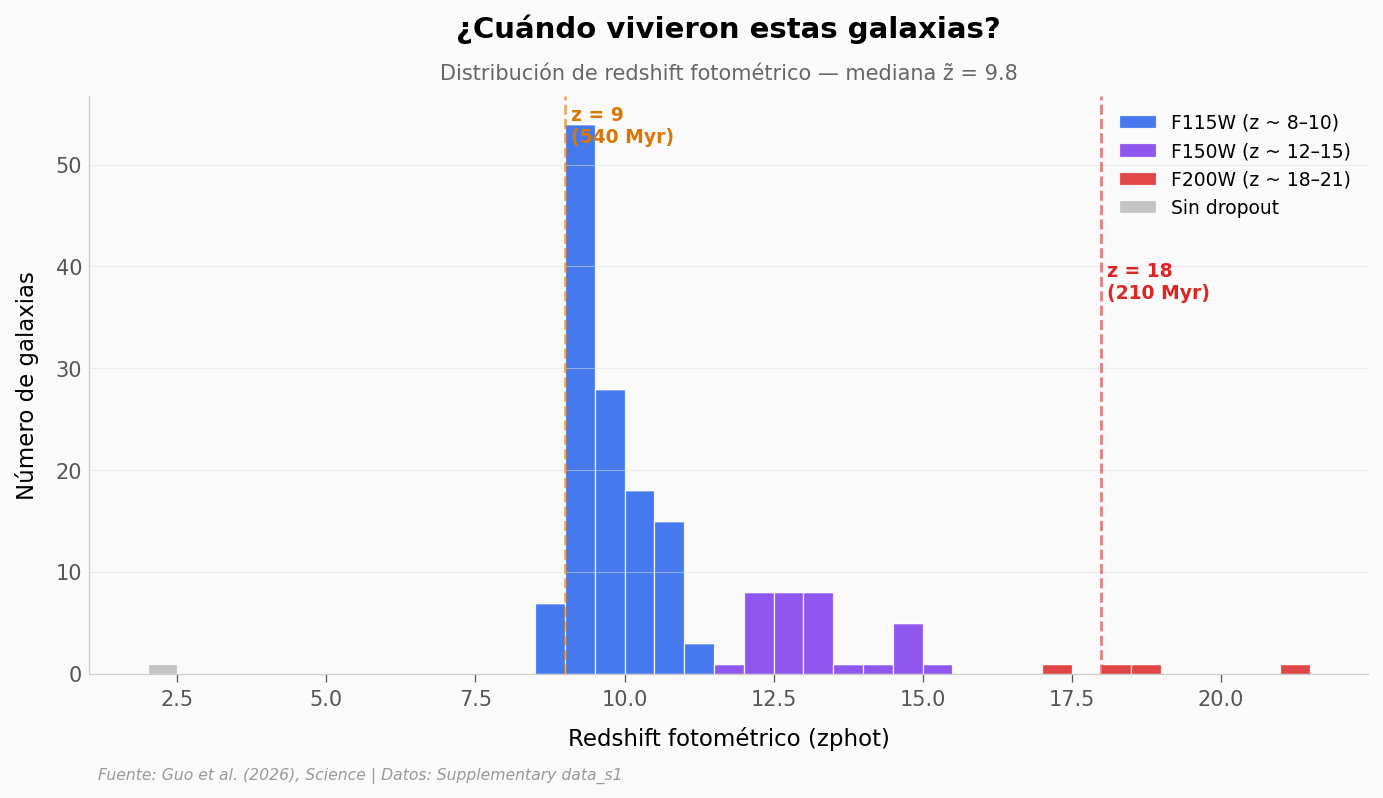

Candidatos con z ≥ 9:  155 (95.1%)
Candidatos con z ≥ 12: 36 (22.1%)
Candidatos con z ≥ 18: 3 (universo < 250 Myr)


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

# Histograma por filtro (apilado)
bins = np.arange(2, 22, 0.5)
data_115 = df[df.drop_out == 'F115W'].zphot
data_150 = df[df.drop_out == 'F150W'].zphot
data_200 = df[df.drop_out == 'F200W'].zphot
data_none = df[df.drop_out.isna()].zphot

ax.hist([data_115, data_150, data_200, data_none], bins=bins, stacked=True,
        color=[COLOR_F115W, COLOR_F150W, COLOR_F200W, '#BBBBBB'],
        label=['F115W (z ~ 8–10)', 'F150W (z ~ 12–15)', 'F200W (z ~ 18–21)', 'Sin dropout'],
        edgecolor='white', linewidth=0.6, alpha=0.85)

# Líneas de referencia
ax.axvline(x=9, color=COLOR_REFERENCIA, linewidth=1.3, linestyle='--', alpha=0.6)
ax.text(9.1, ax.get_ylim()[1]*0.92, 'z = 9\n(540 Myr)', fontsize=9,
        color=COLOR_REFERENCIA, fontweight='bold')
ax.axvline(x=18, color=COLOR_ALERTA, linewidth=1.3, linestyle='--', alpha=0.6)
ax.text(18.1, ax.get_ylim()[1]*0.65, 'z = 18\n(210 Myr)', fontsize=9,
        color=COLOR_ALERTA, fontweight='bold')

ax.set_title('¿Cuándo vivieron estas galaxias?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de redshift fotométrico — mediana z̃ = 9.8',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Redshift fotométrico (zphot)', fontsize=11)
ax.set_ylabel('Número de galaxias', fontsize=11)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_redshift.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticos clave
n_z9 = (df.zphot >= 9).sum()
n_z12 = (df.zphot >= 12).sum()
n_z18 = (df.zphot >= 18).sum()
print(f'Candidatos con z ≥ 9:  {n_z9} ({100*n_z9/len(df):.1f}%)')
print(f'Candidatos con z ≥ 12: {n_z12} ({100*n_z12/len(df):.1f}%)')
print(f'Candidatos con z ≥ 18: {n_z18} (universo < 250 Myr)')

## ¿Y qué tan brillantes son?

`MUV` es la **magnitud absoluta** en el ultravioleta en reposo (rest-frame). Funciona al revés que la intuición: **valores más negativos = galaxia más brillante**. La Vía Láctea tiene MUV ≈ −20.5. MUV = −18 es lo que las búsquedas previas a ASTERIS podían alcanzar de forma confiable a esos redshifts.

Crucemos brillo con redshift.

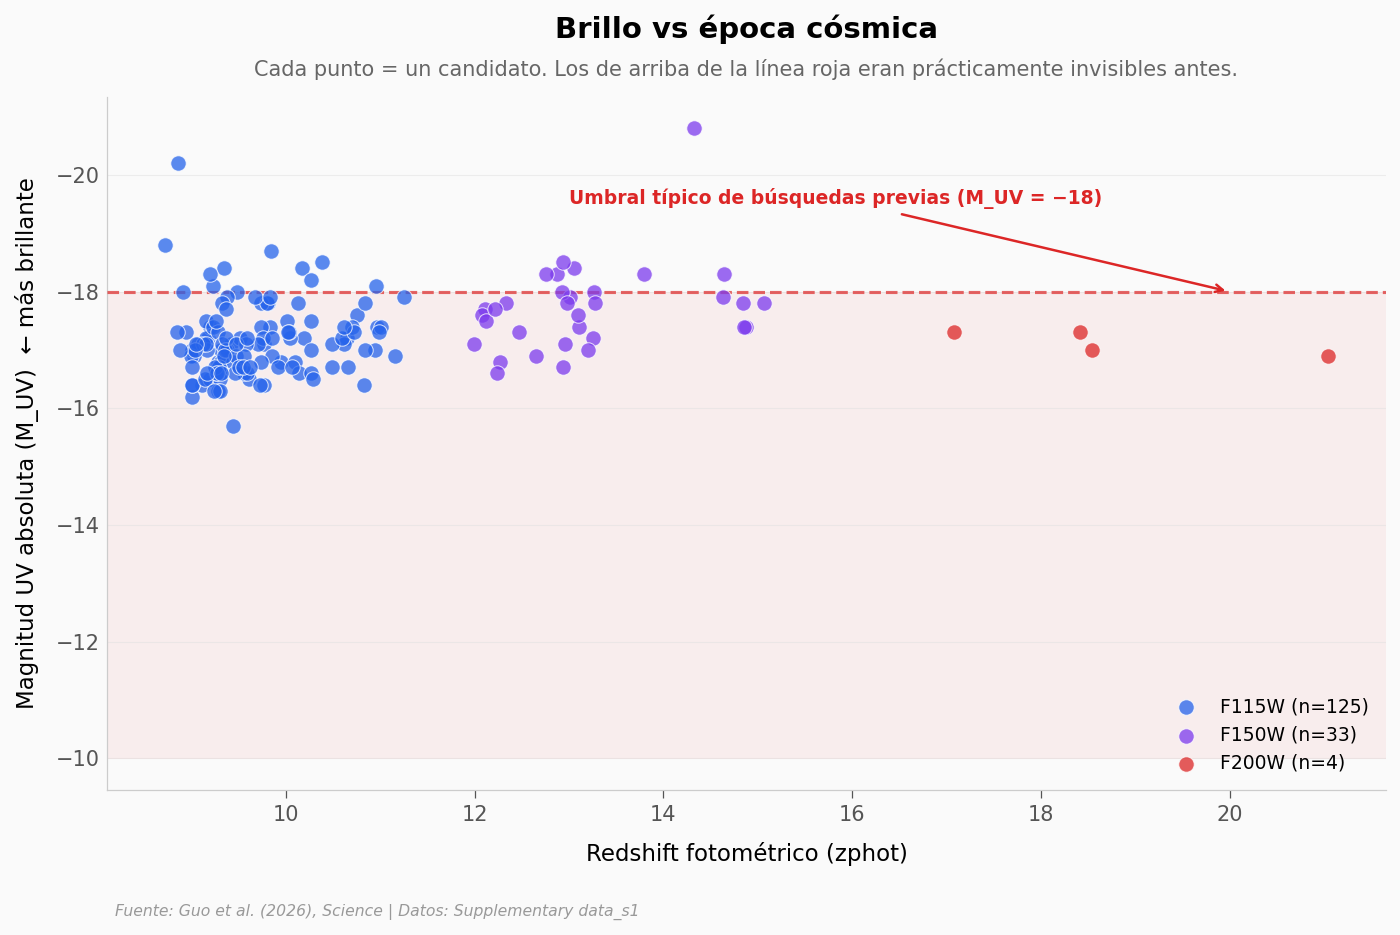

Candidatos más débiles que el umbral típico (M_UV > -18): 142/163 (87.1%)
Mediana M_UV del catálogo: -17.20
Galaxia más brillante: M_UV = -20.8
Galaxia más débil:    M_UV = -11.1


In [4]:
fig, ax = plt.subplots(figsize=(11, 6))

# Scatter coloreado por filtro
for fname, color in [('F115W', COLOR_F115W), ('F150W', COLOR_F150W), ('F200W', COLOR_F200W)]:
    sub = df[df.drop_out == fname]
    if len(sub) == 0:
        continue
    ax.scatter(sub.zphot, sub.MUV, s=55, color=color, alpha=0.75,
               edgecolors='white', linewidths=0.5, zorder=5,
               label=f'{fname} (n={len(sub)})')

# Línea horizontal: umbral tradicional MUV = -18
ax.axhline(y=MUV_UMBRAL_TRADICIONAL, color=COLOR_ALERTA, linewidth=1.5,
           linestyle='--', alpha=0.7, zorder=3)
ax.annotate('Umbral típico de búsquedas previas (M_UV = −18)',
            xy=(20, -18), xytext=(13, -19.5),
            fontsize=9, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.2))

# Sombrear zona "más débiles que el umbral"
ax.axhspan(-18, ax.get_ylim()[1] if False else -10, alpha=0.06, color=COLOR_ALERTA, zorder=1)

ax.set_title('Brillo vs época cósmica',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto = un candidato. Los de arriba de la línea roja eran prácticamente invisibles antes.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Redshift fotométrico (zphot)', fontsize=11)
ax.set_ylabel('Magnitud UV absoluta (M_UV)  ← más brillante', fontsize=11)
ax.invert_yaxis()  # convención astronómica
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_brillo_redshift.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticos del cruce
n_debiles = (df.MUV > MUV_UMBRAL_TRADICIONAL).sum()
pct_debiles = 100 * n_debiles / len(df)
print(f'Candidatos más débiles que el umbral típico (M_UV > -18): {n_debiles}/{len(df)} ({pct_debiles:.1f}%)')
print(f'Mediana M_UV del catálogo: {df.MUV.median():.2f}')
print(f'Galaxia más brillante: M_UV = {df.MUV.min():.1f}')
print(f'Galaxia más débil:    M_UV = {df.MUV.max():.1f}')

## ¿Qué tan débiles son comparadas con el límite tradicional?

El paper afirma que ASTERIS **mejora el límite de detección en 1.0 magnitud** (un factor de ~2.5x en flujo). Eso significa que galaxias que antes quedaban enterradas bajo el ruido ahora aparecen como detecciones confiables. Veamos esa mejora reflejada en la distribución del catálogo.

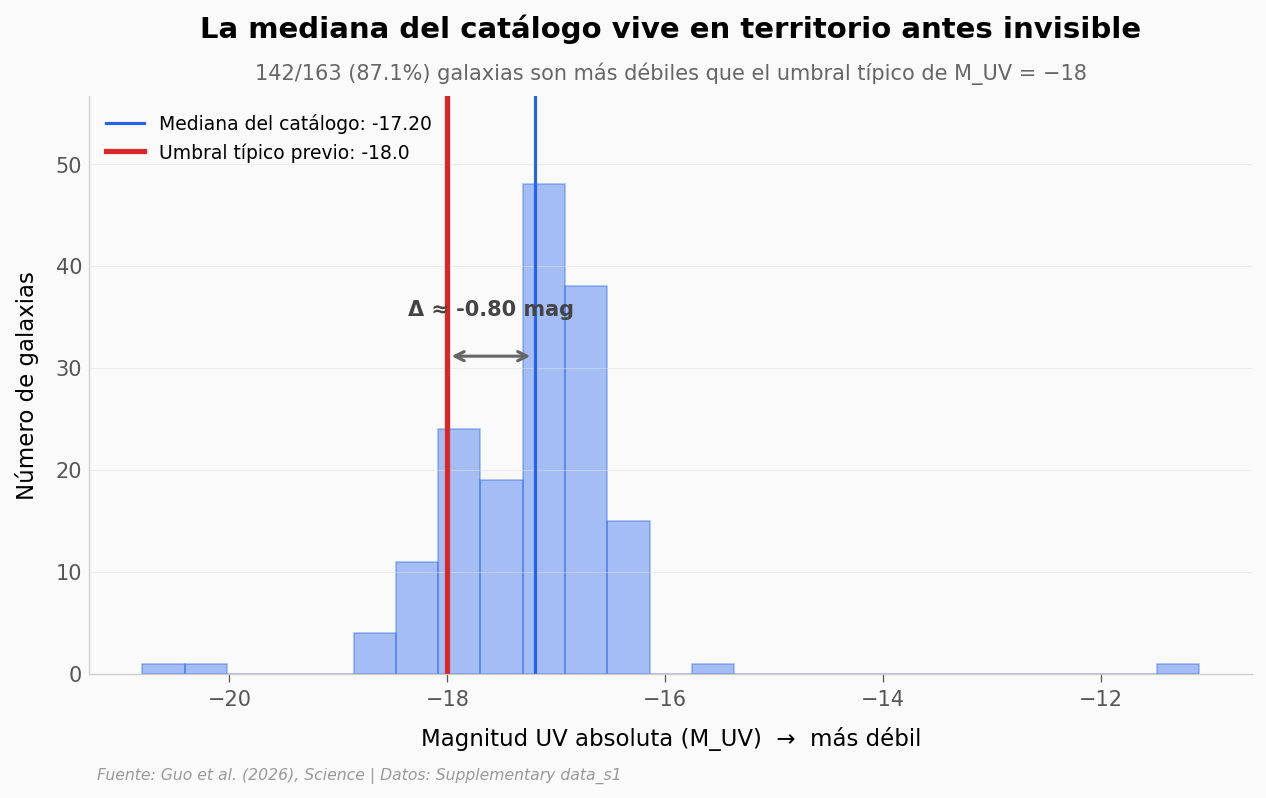

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(df.MUV, bins=25, color=COLOR_DATOS, alpha=0.4,
                            edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

mediana_muv = df.MUV.median()
ax.axvline(x=mediana_muv, color=COLOR_DATOS, linewidth=1.5,
           label=f'Mediana del catálogo: {mediana_muv:.2f}')
ax.axvline(x=MUV_UMBRAL_TRADICIONAL, color=COLOR_ALERTA, linewidth=2.5,
           label=f'Umbral típico previo: {MUV_UMBRAL_TRADICIONAL:.1f}')

# Flecha bidireccional mostrando el "1.0 magnitud" de mejora
ax.annotate('', xy=(mediana_muv, y_max*0.55), xytext=(MUV_UMBRAL_TRADICIONAL, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
delta = MUV_UMBRAL_TRADICIONAL - mediana_muv
ax.text((mediana_muv + MUV_UMBRAL_TRADICIONAL)/2, y_max*0.62,
        f'Δ ≈ {delta:.2f} mag', ha='center', fontsize=10,
        fontweight='bold', color='#444444')

ax.set_title('La mediana del catálogo vive en territorio antes invisible',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'{(df.MUV > MUV_UMBRAL_TRADICIONAL).sum()}/{len(df)} ({100*(df.MUV > MUV_UMBRAL_TRADICIONAL).sum()/len(df):.1f}%) '
        'galaxias son más débiles que el umbral típico de M_UV = −18',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Magnitud UV absoluta (M_UV)  →  más débil', fontsize=11)
ax.set_ylabel('Número de galaxias', fontsize=11)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_anomalia_muv.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| ASTERIS encontró 163 candidatos a galaxias high-z en JWST GOODS-South | ✅ | Conteo directo del catálogo. Una fila tiene `drop_out='None'` y *zphot* = 2.08, claramente un interloper de baja-z (lo dejamos visible en las gráficas) |
| 95.1% del catálogo está en *z* ≥ 9 | ✅ | 155/163 filas con *zphot* ≥ 9 |
| Existen candidatos extremos en *z* ≥ 18 (universo < 250 Myr) | ✅ | 3 candidatos con *zphot* ≥ 18, todos F200W dropouts |
| El 87.1% del catálogo es más débil que M_UV = −18 (umbral típico previo) | ✅ | 142/163 filas con M_UV > −18. Mediana M_UV = −17.20 |
| ASTERIS mejora el límite de detección en 1.0 magnitud (factor ~2.5x) | 🟡 | El paper lo demuestra con *mock data* y benchmarks internos. Aquí no podemos reproducirlo: tenemos el catálogo final, no la comparación contra el método previo en el mismo dato |
| ASTERIS encuentra 3× más candidatos *z* ≳ 9 que métodos previos | 🟡 | Misma limitación: el paper hace la comparación en su Tabla extendida, los datasets de baseline no están en este `data_s1` |
| Preserva la PSF y la fotometría | 🟡 | Validación interna del algoritmo (figuras del paper), no observable en `data_s1` |

> **Limitaciones del análisis:**
>
> - `data_s1` contiene solo el **catálogo final** procesado por ASTERIS — no incluye el dato bruto del JWST ni el catálogo equivalente de un método clásico. Las comparaciones "3× más" y "1.0 magnitud mejor" vienen del paper, no de este notebook.
> - La columna `drop_out` codifica el filtro JWST donde la galaxia desaparece, lo que da el rango de redshift. Una fila tiene `drop_out='None'` (sin dropout claro): probablemente un interloper.
> - El `zphot` es **fotométrico**, no espectroscópico. Los redshifts más extremos (*z* ≥ 18) son candidatos — necesitan confirmación con espectroscopía JWST/NIRSpec, que no está en este dataset.
> - Las medianas, IQR y conteos son reproducibles ejecutando este notebook. Si modificas `MUV_UMBRAL_TRADICIONAL` en la celda de configuración, todas las cifras se recalculan.

## Ahora tú

1. **¿Qué pasa si bajamos el umbral?** ¿Cuántas galaxias quedan más débiles que M_UV = −16? ¿Y más brillantes que M_UV = −19?
2. **¿Hay correlación entre filtro dropout y M_UV?** Las galaxias que se ven en F200W (las extremas en *z*) ¿son sistemáticamente más débiles, o más brillantes, que las F115W?
3. **¿Cómo se distribuye el campo en el cielo?** ¿Hay estructuras (cúmulos, vacíos), o los candidatos están aleatoriamente repartidos?

Pista: cambia el valor de `MUV_UMBRAL_TRADICIONAL` en la celda de configuración y vuelve a correr. O usa el bloque experimental abajo.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: ¿las galaxias en F200W (las extremas) son más débiles que las F115W?

print('M_UV por filtro dropout:')
print(df.groupby('drop_out').MUV.agg(['count', 'median', 'mean', 'std']).round(2))

print('\nzphot por filtro dropout:')
print(df.groupby('drop_out').zphot.agg(['count', 'median', 'mean', 'std']).round(2))

# Test rápido: ¿M_UV de F115W vs F200W?
from scipy import stats
m_115 = df[df.drop_out == 'F115W'].MUV
m_200 = df[df.drop_out == 'F200W'].MUV
u, p = stats.mannwhitneyu(m_115, m_200, alternative='two-sided')
print(f'\nMann–Whitney F115W vs F200W (M_UV): U={u:.0f}, p={p:.3f}')
print(f'(con n_F200W = {len(m_200)}, la potencia es muy baja — solo descriptivo)')

M_UV por filtro dropout:
          count  median   mean   std
drop_out                            
F115W       125  -17.10 -17.15  0.63
F150W        33  -17.70 -17.72  0.75
F200W         4  -17.15 -17.12  0.21

zphot por filtro dropout:
          count  median   mean   std
drop_out                            
F115W       125    9.51   9.69  0.61
F150W        33   12.98  13.19  0.93
F200W         4   18.48  18.77  1.65



Mann–Whitney F115W vs F200W (M_UV): U=270, p=0.785
(con n_F200W = 4, la potencia es muy baja — solo descriptivo)


## Fuentes

**Paper**: [Deeper detection limits in astronomical imaging using self-supervised spatiotemporal denoising](https://doi.org/10.1126/science.ady9404)  
*Science, 2026-02-19*

**Dataset canónico**: [ASTERIS: demonstration datasets](https://doi.org/10.5281/zenodo.17105027)  
*Zenodo, 2025* — *referenciado, no descargado en este notebook (2.3 GB de FITS); el catálogo derivado data_s1 cubre los claims numéricos*

**Código fuente**: [ASTERIS: Deeper detection limits in astronomical imaging using self-supervised spatiotemporal denoising (codigo)](https://doi.org/10.5281/zenodo.17115038) — *Zenodo, open source*

*13 afirmaciones del notebook verificadas contra estas fuentes*

---

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · *Reproducible bajo licencia abierta*